In [16]:
from idlelib.editor import darwin

#Loading data as .csv file
#Creating pandas data_frame based on loaded .csv file
import kagglehub
import pandas as pd
from os import listdir, path
path_to_the_data = kagglehub.dataset_download("ahsanneural/future-jobs-and-skills-demand-2025")
files = listdir(path_to_the_data)
true_path = path.join(path_to_the_data, files[0])
data_frame = pd.read_csv(true_path)

In [17]:
#First look at our data_frame
data_frame.head()

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"Linear Algebra, Quantum Algorithms",No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"Climate Data Analysis, Energy Modeling",Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"Linear Algebra, Qiskit",No,Medium,2025-12-31
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"Climate Data Analysis, Energy Modeling",No,Large,2025-05-29
4,5,Smart Contract Engineer,Blockchain,London,92575,"Rust, Solidity",Yes,Small,2025-03-30


In [29]:
#I'm extracting only data that is interesting for me, in this case I leave only rows that poses information about Quantum Computing industry
qc_info_df = data_frame.loc[data_frame["industry"] == "Quantum Computing",["industry","skills_required"]]
#I don't need rows where industry or skills_requried is nan so I drop them
qc_info_df = qc_info_df.dropna(subset=["industry","skills_required"])
#I would like to know which skill is most required skill for position in Quantum Computing industry so I need to split every row on two rows
qc_info_df["skills_required"] = qc_info_df["skills_required"].apply( lambda x : [i.lower().strip() for i in x.split(',')])
qc_info_df = qc_info_df.explode("skills_required").reset_index(drop=True)
qc_info_df.head()


,industry,skills_required
0,Quantum Computing,linear algebra
1,Quantum Computing,quantum algorithms
2,Quantum Computing,linear algebra
3,Quantum Computing,qiskit
4,Quantum Computing,qiskit


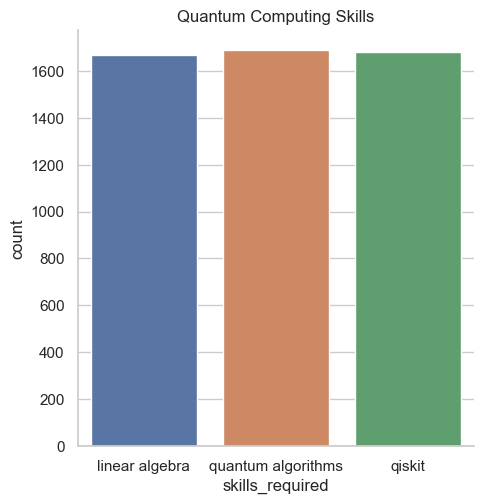

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.catplot(x="skills_required",data=qc_info_df,kind="count",hue="skills_required")
sns.set_theme(style="whitegrid")
plt.title("Quantum Computing Skills")
plt.show()